House Price Prediction In India

Import  Libraries

In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder

Import Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anmolkumar/house-price-prediction-challenge")

print("Path to dataset files:", path)

100%|██████████| 2.13M/2.13M [00:00<00:00, 162MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/anmolkumar/house-price-prediction-challenge/versions/1


Understand the Dataset

In [ ]:
hp=pd.read_csv(f'{path}/train.csv')
hp.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


In [ ]:
hp.shape

(29451, 12)

In [ ]:
hp.isna().sum()

,0
POSTED_BY,0
UNDER_CONSTRUCTION,0
RERA,0
BHK_NO.,0
BHK_OR_RK,0
SQUARE_FT,0
READY_TO_MOVE,0
RESALE,0
ADDRESS,0
LONGITUDE,0


In [ ]:
hp.duplicated().sum()

np.int64(401)

In [ ]:
hp=hp.drop_duplicates()

In [ ]:
hp.shape

(29050, 12)

Exploratory Data Analysis

In [ ]:
hp['BHK_OR_RK'].value_counts()

,count
BHK_OR_RK,
BHK,29026
RK,24


In [ ]:
hp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29050 entries, 0 to 29450
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   POSTED_BY              29050 non-null  object 
 1   UNDER_CONSTRUCTION     29050 non-null  int64  
 2   RERA                   29050 non-null  int64  
 3   BHK_NO.                29050 non-null  int64  
 4   BHK_OR_RK              29050 non-null  object 
 5   SQUARE_FT              29050 non-null  float64
 6   READY_TO_MOVE          29050 non-null  int64  
 7   RESALE                 29050 non-null  int64  
 8   ADDRESS                29050 non-null  object 
 9   LONGITUDE              29050 non-null  float64
 10  LATITUDE               29050 non-null  float64
 11  TARGET(PRICE_IN_LACS)  29050 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 2.9+ MB


In [ ]:
hp.describe()

,UNDER_CONSTRUCTION,RERA,BHK_NO.,SQUARE_FT,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
count,29050.000000,29050.000000,29050.000000,2.905000e+04,29050.000000,29050.000000,29050.000000,29050.000000,29050.000000
mean,0.178967,0.315869,2.390809,2.003171e+04,0.821033,0.930361,21.270272,76.829585,141.712677
std,0.383332,0.464869,0.880677,1.914411e+06,0.383332,0.254541,6.195973,10.567572,650.055763
min,0.000000,0.000000,1.000000,3.000000e+00,0.000000,0.000000,-37.713008,-121.761248,0.250000
25%,0.000000,0.000000,2.000000,9.000000e+02,1.000000,1.000000,18.452663,73.794800,38.000000
50%,0.000000,0.000000,2.000000,1.172742e+03,1.000000,1.000000,20.631532,77.322873,61.750000
75%,0.000000,1.000000,3.000000,1.550169e+03,1.000000,1.000000,26.886881,77.912934,100.000000
max,1.000000,1.000000,20.000000,2.545455e+08,1.000000,1.000000,59.912884,152.962676,30000.000000


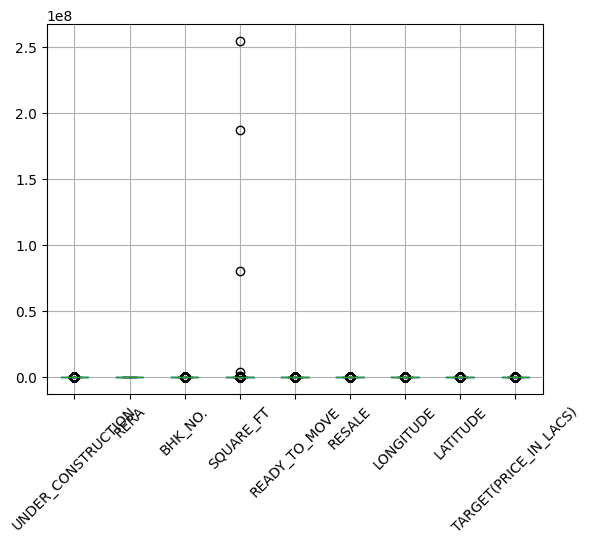

In [ ]:
hp.boxplot()
plt.xticks(rotation=45)
plt.show()


Data Preprocessing

In [ ]:
hp=pd.get_dummies(hp,columns=['BHK_OR_RK','ADDRESS'])

In [ ]:
x=hp.drop(columns=['POSTED_BY','TARGET(PRICE_IN_LACS)'])
y = hp['TARGET(PRICE_IN_LACS)']

Train-Test Split

In [ ]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=43)


Model Prediction

In [ ]:
model = RandomForestRegressor(
    n_estimators=40,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

model.fit(x_train, y_train)

RandomForestRegressor(max_depth=15, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=5, n_estimators=40, n_jobs=-1,
                      random_state=42)

In [ ]:
predict=model.predict(x_test)
predict

array([122.85013449, 138.71349769, 115.55954764, ..., 124.31434507,
       110.37082398, 115.55954764])

In [ ]:
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R² :", r2_score(y_test, test_pred))

Train R²: 0.2715312499535484
Test R² : 0.28817838288121633


In [ ]:
mae = mean_absolute_error(y_test,predict)
print("MAE:", mae)
print("R²:", r2_score(y_test, predict))
rmse=np.sqrt(mean_squared_error(y_test, predict))
print("RMSE:", rmse)

MAE: 120.32230053062005
R²: 0.28817838288121633
RMSE: 461.3774426261328


In [ ]:
pickle.dump(model, open('House-Price-Prediction-RFR.pkl','wb'))
print('pkl file created successfully')

pkl file created successfully


 Feature Importance Analysis

In [44]:
importance = pd.Series(
    model.feature_importances_,
    index=x_train.columns
)

original_importance = pd.Series({
    "ADDRESS": importance[importance.index.str.startswith("ADDRESS_")].sum(),
    "SQUARE_FT": importance["SQUARE_FT"],
    "RESALE": importance["RESALE"],
    "BHK_NO.": importance["BHK_NO."],
    "UNDER_CONSTRUCTION": importance["UNDER_CONSTRUCTION"],
    "RERA": importance["RERA"],
    "READY_TO_MOVE": importance["READY_TO_MOVE"],
    "LONGITUDE": importance["LONGITUDE"],
    "LATITUDE": importance["LATITUDE"]
})

print(original_importance.sort_values(ascending=False)*100)

ADDRESS               37.769133
SQUARE_FT             32.330687
RESALE                17.946905
BHK_NO.                4.484576
UNDER_CONSTRUCTION     2.688287
READY_TO_MOVE          2.118241
RERA                   1.718368
LATITUDE               0.901759
LONGITUDE              0.040741
dtype: float64


Feature Importance Visualization

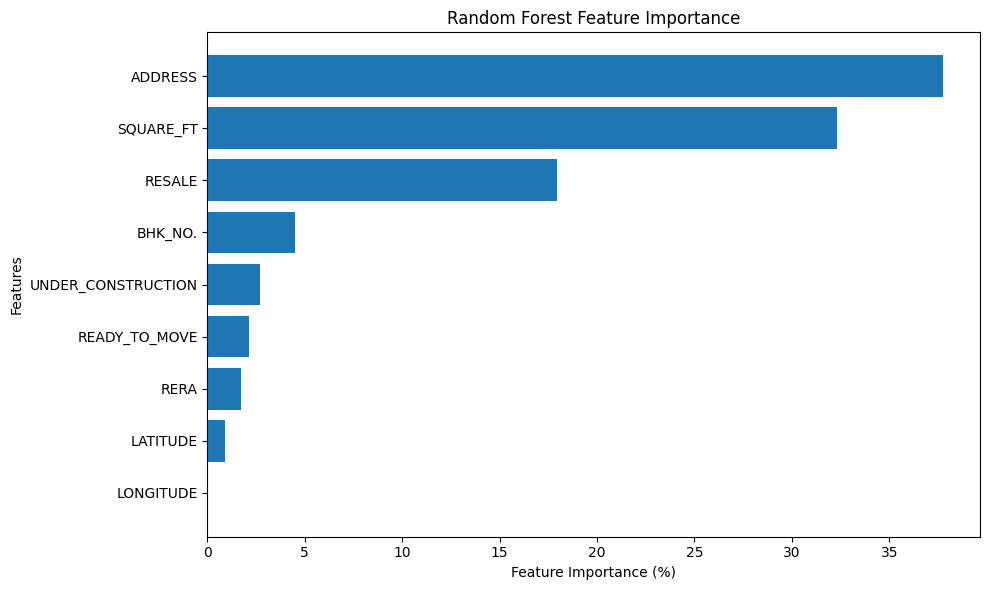

In [52]:
# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    original_importance.index,
    original_importance.values
)

plt.xlabel("Feature Importance (%)")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()